## Sentiment Analysis — TF-IDF Weighted GloVe Embeddings
### Dataset: Yelp Academic Dataset (1.8M reviews, 3-class balanced)
### Approach: Weight each word's GloVe vector by its TF-IDF score before averaging
### Hypothesis: TF-IDF weighting preserves important words, reduces noise from common words
### Baseline to beat: TF-IDF + Logistic Regression → 0.7991 F1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from scipy.sparse import issparse

# paths
PROC_PATH  = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\data\processed"
MODELS_DIR = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\models"
FIGURES    = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\figures"
GLOVE_PATH = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\glove\glove.6B.100d.txt"

LABELS = ['Negative', 'Neutral', 'Positive']

## 1. Load Data & GloVe Vectors

In [2]:
# load cleaned data
df = pd.read_csv(os.path.join(PROC_PATH, 'reviews_clean.csv'))
df = df.dropna(subset=['clean_text']).reset_index(drop=True)
print(f"Data shape : {df.shape}")

# load glove
def load_glove(path):
    glove = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
    return glove

print("Loading GloVe vectors...")
glove = load_glove(GLOVE_PATH)
print(f"GloVe vocabulary : {len(glove):,} words")

Data shape : (1798312, 3)
Loading GloVe vectors...
GloVe vocabulary : 400,000 words


## 2. Build TF-IDF Weight Lookup
Fit TF-IDF on the corpus to get per-word IDF weights.
These weights tell us how important each word is globally.
High IDF = rare, informative word → gets more weight
Low IDF  = common word → gets less weight

In [3]:
print("Fitting TF-IDF for word weights...")

tfidf_weighter = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 1),   # unigrams only for word-level weighting
    sublinear_tf=True,
    min_df=5,
    max_df=0.95
)

tfidf_weighter.fit(df['clean_text'])

# word → idf weight dictionary
vocab    = tfidf_weighter.vocabulary_          # word → index
idf_vals = tfidf_weighter.idf_                 # index → idf value
word_idf = {word: idf_vals[idx] for word, idx in vocab.items()}

print(f"Vocabulary size : {len(word_idf):,}")
print(f"\nSample IDF weights:")
sample_words = ['good', 'great', 'terrible', 'food', 'service', 'amazing']
for w in sample_words:
    if w in word_idf:
        print(f"  {w:15} → {word_idf[w]:.4f}")

# save weighter
joblib.dump(tfidf_weighter, os.path.join(MODELS_DIR, 'tfidf_weighter.joblib'))
print("\nSaved → tfidf_weighter.joblib")

Fitting TF-IDF for word weights...
Vocabulary size : 90,909

Sample IDF weights:
  good            → 2.0301
  great           → 2.3415
  terrible        → 4.4497
  food            → 1.9785
  service         → 2.2310
  amazing         → 3.6214

Saved → tfidf_weighter.joblib


## 3. TF-IDF Weighted GloVe Vectorization
For each review:
1. Tokenize
2. For each token → get GloVe vector × IDF weight
3. Sum weighted vectors → divide by sum of weights
Result: one 100d vector per review, important words contribute more

In [4]:
def review_to_weighted_vector(text, glove, word_idf, dims=100):
    tokens       = str(text).split()
    weighted_sum = np.zeros(dims, dtype=np.float32)
    total_weight = 0.0

    for token in tokens:
        if token in glove and token in word_idf:
            weight        = word_idf[token]
            weighted_sum += glove[token] * weight
            total_weight += weight

    if total_weight == 0:
        return np.zeros(dims)
    
    return weighted_sum / total_weight

print("Converting reviews to TF-IDF weighted GloVe vectors...")
print("This will take several minutes...")

X = np.vstack(
    df['clean_text'].apply(
        lambda x: review_to_weighted_vector(x, glove, word_idf)
    ).values
)
y = df['label'].values

print(f"Feature matrix shape : {X.shape}")

# save
np.save(os.path.join(PROC_PATH, 'X_glove_weighted.npy'), X)
print("Saved → X_glove_weighted.npy")

Converting reviews to TF-IDF weighted GloVe vectors...
This will take several minutes...
Feature matrix shape : (1798312, 100)
Saved → X_glove_weighted.npy


## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (1438649, 100)
Test  : (359663, 100)


## 5. Train & Evaluate Models

In [6]:
weighted_results = {}

def train_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    print(f"\n{'='*50}")
    print(f"Training : {name}")
    print('='*50)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    f1    = f1_score(y_te, preds, average='weighted')

    print(classification_report(y_te, preds, target_names=LABELS))

    cm = confusion_matrix(y_te, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f'Confusion Matrix — Weighted GloVe + {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    fname = f"confusion_matrix_weighted_glove_{name.lower().replace(' ','_')}.png"
    plt.savefig(os.path.join(FIGURES, fname), dpi=150)
    plt.show()
    print(f"Saved → {fname}")

    weighted_results[name] = {'model': model, 'f1': round(f1, 4)}
    return model

### 5a. Logistic Regression


Training : Logistic Regression
              precision    recall  f1-score   support

    Negative       0.71      0.73      0.72    119872
     Neutral       0.56      0.55      0.55    119842
    Positive       0.69      0.68      0.68    119949

    accuracy                           0.65    359663
   macro avg       0.65      0.65      0.65    359663
weighted avg       0.65      0.65      0.65    359663



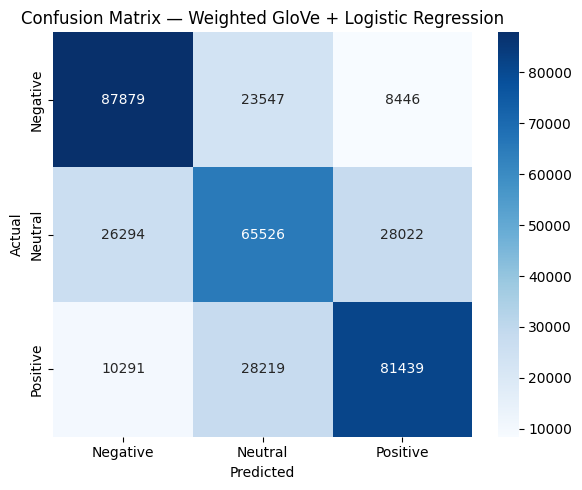

Saved → confusion_matrix_weighted_glove_logistic_regression.png


In [7]:
lr_weighted = train_evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train, X_test, y_train, y_test
)

### 5b. Linear SVM


Training : Linear SVM
              precision    recall  f1-score   support

    Negative       0.68      0.76      0.72    119872
     Neutral       0.58      0.48      0.52    119842
    Positive       0.67      0.71      0.69    119949

    accuracy                           0.65    359663
   macro avg       0.64      0.65      0.64    359663
weighted avg       0.64      0.65      0.64    359663



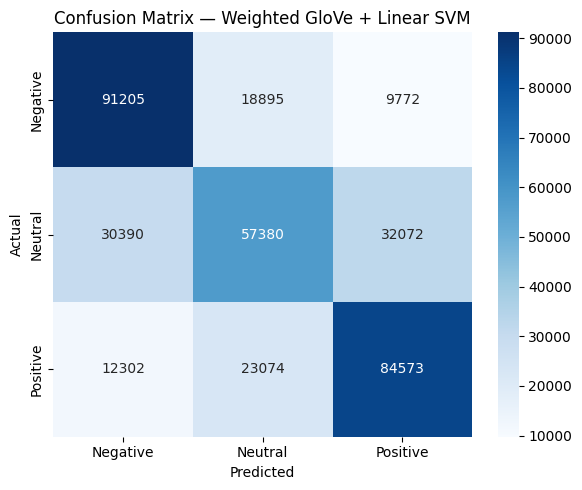

Saved → confusion_matrix_weighted_glove_linear_svm.png


In [8]:
svm_weighted = train_evaluate(
    'Linear SVM',
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train, X_test, y_train, y_test
)

## 6. Results Comparison

              Model  Weighted F1
Logistic Regression       0.6523
         Linear SVM       0.6430


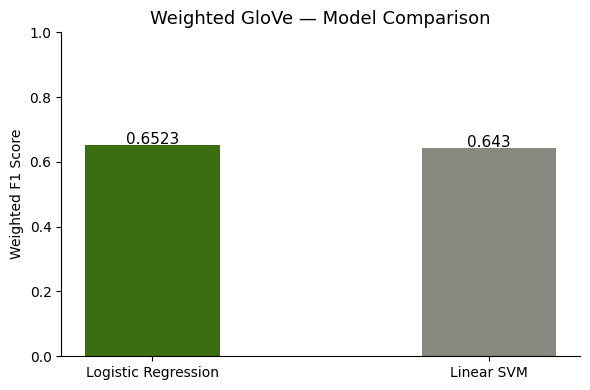

Saved → reports/weighted_glove_results.csv


In [9]:
comparison_weighted = pd.DataFrame([
    {'Model': name, 'Weighted F1': info['f1']}
    for name, info in weighted_results.items()
]).sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print(comparison_weighted.to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(6, 4))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(comparison_weighted))]
bars    = ax.bar(comparison_weighted['Model'],
                 comparison_weighted['Weighted F1'],
                 color=colors, width=0.4)

for bar, val in zip(bars, comparison_weighted['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            str(val), ha='center', fontsize=11)

ax.set_title('Weighted GloVe — Model Comparison', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'weighted_glove_comparison.png'), dpi=150)
plt.show()

comparison_weighted.to_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\weighted_glove_results.csv",
    index=False
)
print("Saved → reports/weighted_glove_results.csv")

## 7. Full Pipeline Comparison — All Approaches

=== FULL PIPELINE COMPARISON ===
        Approach               Model  Weighted F1
          TF-IDF Logistic Regression       0.7991
          TF-IDF          Linear SVM       0.7973
          TF-IDF         Naive Bayes       0.7521
     GloVe (avg) Logistic Regression       0.6745
     GloVe (avg)          Linear SVM       0.6664
GloVe (weighted) Logistic Regression       0.6523
GloVe (weighted)          Linear SVM       0.6430


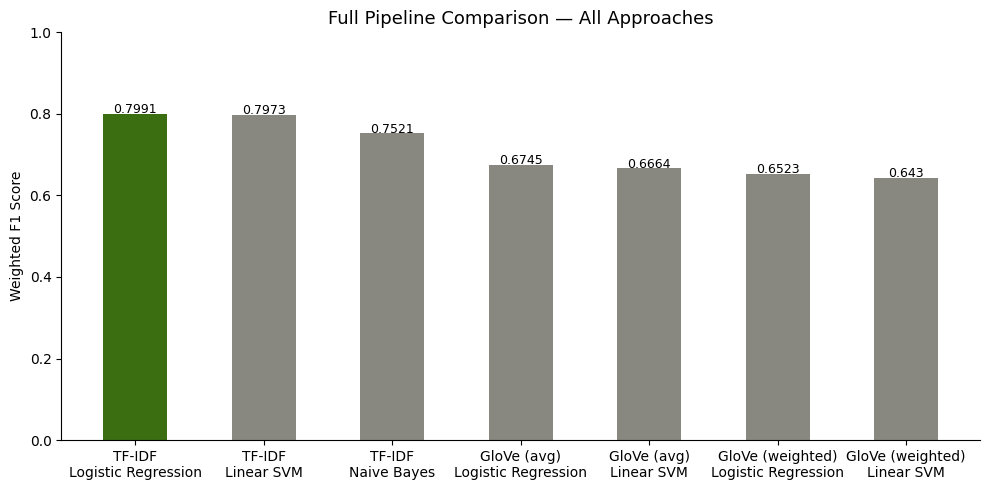

Saved → reports/full_comparison.csv


In [10]:
tfidf_df   = pd.read_csv(r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\tfidf_results.csv")
glove_df   = pd.read_csv(r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\glove_results.csv")

tfidf_df['Approach']   = 'TF-IDF'
glove_df['Approach']   = 'GloVe (avg)'
comparison_weighted['Approach'] = 'GloVe (weighted)'

final = pd.concat([tfidf_df, glove_df, comparison_weighted], ignore_index=True)
final = final.sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print("=== FULL PIPELINE COMPARISON ===")
print(final[['Approach', 'Model', 'Weighted F1']].to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(final))]
bars    = ax.bar(
    [f"{r['Approach']}\n{r['Model']}" for _, r in final.iterrows()],
    final['Weighted F1'],
    color=colors, width=0.5
)

for bar, val in zip(bars, final['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            str(val), ha='center', fontsize=9)

ax.set_title('Full Pipeline Comparison — All Approaches', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'full_pipeline_comparison.png'), dpi=150)
plt.show()

final.to_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\full_comparison.csv",
    index=False
)
print("Saved → reports/full_comparison.csv")

In [11]:
best_name  = comparison_weighted.iloc[0]['Model']
best_model = weighted_results[best_name]['model']
best_f1    = comparison_weighted.iloc[0]['Weighted F1']

joblib.dump(best_model, os.path.join(MODELS_DIR, 'glove_weighted_best_model.joblib'))

print(f"Best weighted GloVe model : {best_name}")
print(f"Weighted F1               : {best_f1}")
print(f"Saved → models/glove_weighted_best_model.joblib")

Best weighted GloVe model : Logistic Regression
Weighted F1               : 0.6523
Saved → models/glove_weighted_best_model.joblib


## 8. Summary

| Approach | Best Model | Weighted F1 |
|---|---|---|
| TF-IDF | Logistic Regression | 0.7991 |
| GloVe avg pooling | Logistic Regression | 0.6745 |
| GloVe TF-IDF weighted | TBD | TBD |

**Key insight:**
TF-IDF weighting on GloVe vectors gives important words 
more influence, reducing noise from frequent but meaningless words.

**Next step → 05_bert.ipynb on Google Colab with GPU**